In [1]:
!pip install -q statsmodels tqdm pyyaml

In [2]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from tqdm.auto import tqdm

In [3]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [4]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/BIL401_Regime_Head_Pruning"
)

REGIME_DIR = PROJECT_DIR / "regime_detection"
REGIME_DIR.mkdir(parents=True, exist_ok=True)

print(REGIME_DIR)

/content/drive/MyDrive/BIL401_Regime_Head_Pruning/regime_detection


In [5]:
%cd /content

!git clone https://github.com/thuml/Time-Series-Library.git

/content
Cloning into 'Time-Series-Library'...
remote: Enumerating objects: 2295, done.
remote: Total 2295 (delta 0), reused 0 (delta 0), pack-reused 2295 (from 1)
Receiving objects: 100% (2295/2295), 78.43 MiB | 29.16 MiB/s, done.
Resolving deltas: 100% (1570/1570), done.


In [6]:
from pathlib import Path

data_dir = Path(
    "/content/Time-Series-Library/"
    "dataset/ETDataset/ETT-small"
)

data_dir.mkdir(parents=True, exist_ok=True)

!wget -q \
  https://raw.githubusercontent.com/zhouhaoyi/ETDataset/main/ETT-small/ETTh1.csv \
  -O /content/Time-Series-Library/dataset/ETDataset/ETT-small/ETTh1.csv

In [7]:
data_path = Path(
    "/content/Time-Series-Library/"
    "dataset/ETDataset/ETT-small/ETTh1.csv"
)

print("Dosya mevcut mu?:", data_path.exists())
print("Dosya boyutu:", data_path.stat().st_size if data_path.exists() else 0)

Dosya mevcut mu?: True
Dosya boyutu: 2589657


In [8]:
import pandas as pd

df = pd.read_csv(data_path)

print("Veri boyutu:", df.shape)
print("Kolonlar:", df.columns.tolist())

display(df.head())

Veri boyutu: (17420, 8)
Kolonlar: ['date', 'HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']


,date,HUFL,HULL,MUFL,MULL,LUFL,LULL,OT
0,2016-07-01 00:00:00,5.827,2.009,1.599,0.462,4.203,1.340,30.531000
1,2016-07-01 01:00:00,5.693,2.076,1.492,0.426,4.142,1.371,27.787001
2,2016-07-01 02:00:00,5.157,1.741,1.279,0.355,3.777,1.218,27.787001
3,2016-07-01 03:00:00,5.090,1.942,1.279,0.391,3.807,1.279,25.044001
4,2016-07-01 04:00:00,5.358,1.942,1.492,0.462,3.868,1.279,21.948000


In [9]:
SEQ_LEN = 336
PRED_LEN = 96

TRAIN_SIZE = 12 * 30 * 24
VAL_SIZE = 4 * 30 * 24

val_border1 = TRAIN_SIZE - SEQ_LEN
val_border2 = TRAIN_SIZE + VAL_SIZE

validation_segment = df.iloc[
    val_border1:val_border2
].reset_index(drop=True)

print("Validation segment boyutu:", validation_segment.shape)
print("Başlangıç:", validation_segment["date"].iloc[0])
print("Bitiş:", validation_segment["date"].iloc[-1])

Validation segment boyutu: (3216, 8)
Başlangıç: 2017-06-12 00:00:00
Bitiş: 2017-10-23 23:00:00


In [10]:
num_windows = (
    len(validation_segment)
    - SEQ_LEN
    - PRED_LEN
    + 1
)

print("Validation window sayısı:", num_windows)

Validation window sayısı: 2785


In [11]:
import numpy as np

target_series = (
    validation_segment["OT"]
    .astype(float)
    .to_numpy()
)

print("Seri uzunluğu:", len(target_series))
print(target_series[:10])

Seri uzunluğu: 3216
[15.33600044 15.0539999  14.27999973 13.8579998  14.21000004 14.63199997
 14.70300007 14.42099953 14.77299976 14.77299976]


In [12]:
import numpy as np
from statsmodels.tsa.seasonal import STL

def detect_regime_stl(
    window: np.ndarray,
    period: int = 24,
    eps: float = 1e-12,
) -> dict:
    """
    Bir zaman serisi penceresini STL ile trend, seasonal ve residual
    bileşenlerine ayırır.

    Regime, varyansı en yüksek bileşene göre belirlenir.
    """

    window = np.asarray(window, dtype=np.float64)

    if window.ndim != 1:
        raise ValueError("window tek boyutlu olmalıdır.")

    if len(window) < 2 * period:
        raise ValueError(
            f"Pencere çok kısa. En az {2 * period} değer gerekiyor."
        )

    if not np.isfinite(window).all():
        raise ValueError("Pencerede NaN veya sonsuz değer var.")

    stl_result = STL(
        window,
        period=period,
        robust=True,
    ).fit()

    trend = stl_result.trend
    seasonal = stl_result.seasonal
    residual = stl_result.resid

    component_variances = {
        "trend": float(np.var(trend)),
        "seasonal": float(np.var(seasonal)),
        "residual": float(np.var(residual)),
    }

    total_variance = sum(component_variances.values()) + eps

    scores = {
        name: variance / total_variance
        for name, variance in component_variances.items()
    }

    regime = max(scores, key=scores.get)

    return {
        "regime": regime,
        "trend_score": scores["trend"],
        "seasonal_score": scores["seasonal"],
        "residual_score": scores["residual"],
        "trend": trend,
        "seasonal": seasonal,
        "residual": residual,
    }

In [13]:
sample_window = target_series[:SEQ_LEN]

sample_result = detect_regime_stl(
    sample_window,
    period=24,
)

print("Regime:", sample_result["regime"])
print("Trend score:", sample_result["trend_score"])
print("Seasonal score:", sample_result["seasonal_score"])
print("Residual score:", sample_result["residual_score"])

Regime: trend
Trend score: 0.7004758505288651
Seasonal score: 0.2056400964345578
Residual score: 0.09388405303638675


In [14]:
score_sum = (
    sample_result["trend_score"]
    + sample_result["seasonal_score"]
    + sample_result["residual_score"]
)

print("Skor toplamı:", score_sum)

Skor toplamı: 0.9999999999998097


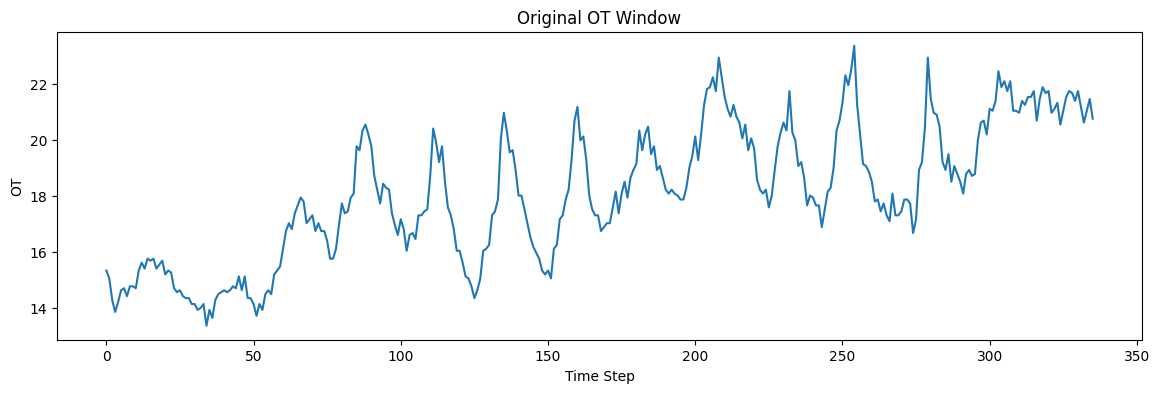

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 4))
plt.plot(sample_window)
plt.title("Original OT Window")
plt.xlabel("Time Step")
plt.ylabel("OT")
plt.show()

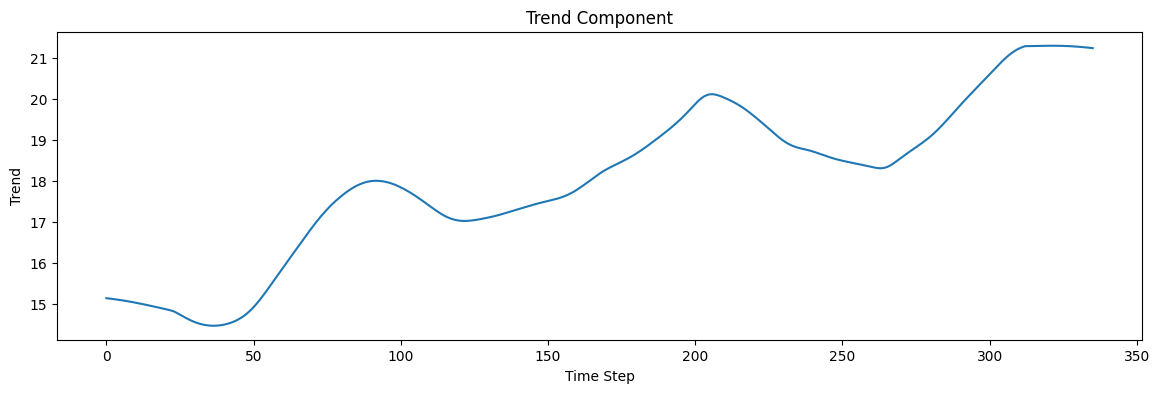

In [16]:
plt.figure(figsize=(14, 4))
plt.plot(sample_result["trend"])
plt.title("Trend Component")
plt.xlabel("Time Step")
plt.ylabel("Trend")
plt.show()

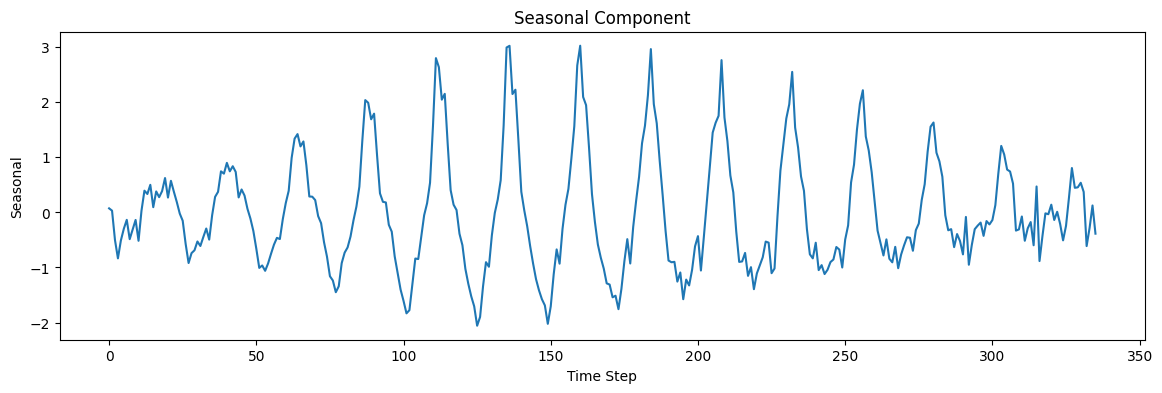

In [17]:
plt.figure(figsize=(14, 4))
plt.plot(sample_result["seasonal"])
plt.title("Seasonal Component")
plt.xlabel("Time Step")
plt.ylabel("Seasonal")
plt.show()

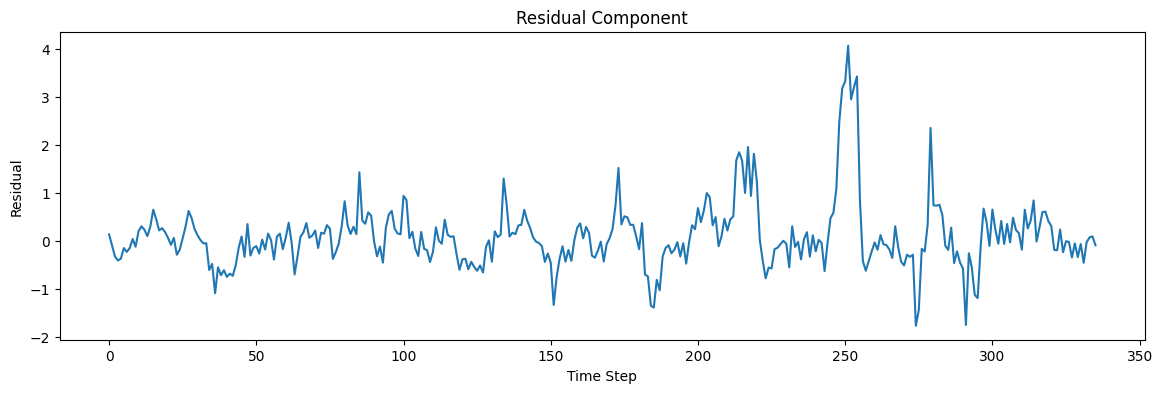

In [18]:
plt.figure(figsize=(14, 4))
plt.plot(sample_result["residual"])
plt.title("Residual Component")
plt.xlabel("Time Step")
plt.ylabel("Residual")
plt.show()

In [19]:
from tqdm.auto import tqdm
import pandas as pd

regime_records = []

for window_id in tqdm(
    range(num_windows),
    desc="STL regime detection",
):
    start_idx = window_id
    end_idx = start_idx + SEQ_LEN

    window = target_series[start_idx:end_idx]

    result = detect_regime_stl(
        window,
        period=24,
    )

    input_start_date = validation_segment.iloc[start_idx]["date"]
    input_end_date = validation_segment.iloc[end_idx - 1]["date"]

    regime_records.append({
        "window_id": window_id,
        "start_idx": start_idx,
        "end_idx": end_idx,
        "input_start_date": input_start_date,
        "input_end_date": input_end_date,
        "trend_score": result["trend_score"],
        "seasonal_score": result["seasonal_score"],
        "residual_score": result["residual_score"],
        "regime": result["regime"],
    })

regime_df = pd.DataFrame(regime_records)

print("Üretilen window sayısı:", len(regime_df))
display(regime_df.head())

STL regime detection:   0%|          | 0/2785 [00:00<?, ?it/s]

Üretilen window sayısı: 2785


,window_id,start_idx,end_idx,input_start_date,input_end_date,trend_score,seasonal_score,residual_score,regime
0,0,0,336,2017-06-12 00:00:00,2017-06-25 23:00:00,0.700476,0.205640,0.093884,trend
1,1,1,337,2017-06-12 01:00:00,2017-06-26 00:00:00,0.700166,0.206039,0.093796,trend
2,2,2,338,2017-06-12 02:00:00,2017-06-26 01:00:00,0.696768,0.208689,0.094543,trend
3,3,3,339,2017-06-12 03:00:00,2017-06-26 02:00:00,0.689886,0.213555,0.096559,trend
4,4,4,340,2017-06-12 04:00:00,2017-06-26 03:00:00,0.677356,0.223502,0.099142,trend


In [20]:
regime_summary = (
    regime_df["regime"]
    .value_counts()
    .rename_axis("regime")
    .reset_index(name="count")
)

regime_summary["percentage"] = (
    regime_summary["count"]
    / len(regime_df)
    * 100
)

display(regime_summary)

,regime,count,percentage
0,trend,2134,76.624776
1,residual,359,12.890485
2,seasonal,292,10.484740


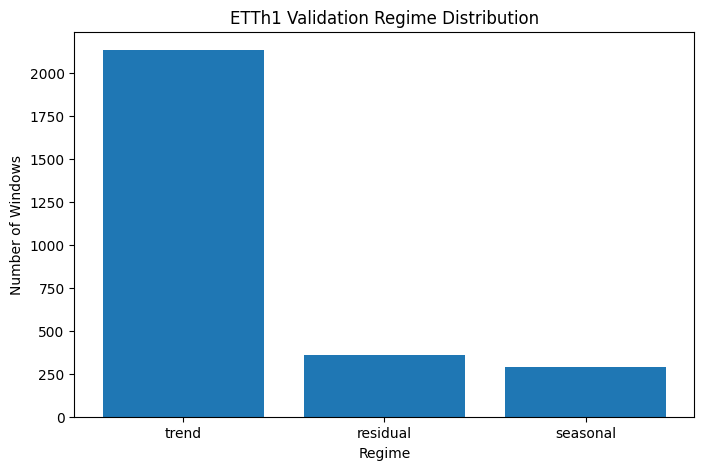

In [21]:
plt.figure(figsize=(8, 5))
plt.bar(
    regime_summary["regime"],
    regime_summary["count"],
)

plt.title("ETTh1 Validation Regime Distribution")
plt.xlabel("Regime")
plt.ylabel("Number of Windows")
plt.show()

In [22]:
regime_output_path = (
    REGIME_DIR
    / "etth1_validation_regimes_ot_seq336.csv"
)

regime_df.to_csv(
    regime_output_path,
    index=False,
)

summary_output_path = (
    REGIME_DIR
    / "etth1_validation_regime_summary.csv"
)

regime_summary.to_csv(
    summary_output_path,
    index=False,
)

print("Window etiketleri:")
print(regime_output_path)

print("\nÖzet:")
print(summary_output_path)

Window etiketleri:
/content/drive/MyDrive/BIL401_Regime_Head_Pruning/regime_detection/etth1_validation_regimes_ot_seq336.csv

Özet:
/content/drive/MyDrive/BIL401_Regime_Head_Pruning/regime_detection/etth1_validation_regime_summary.csv


In [23]:
top_trend = (
    regime_df
    .sort_values("trend_score", ascending=False)
    .head(5)
)

top_seasonal = (
    regime_df
    .sort_values("seasonal_score", ascending=False)
    .head(5)
)

top_residual = (
    regime_df
    .sort_values("residual_score", ascending=False)
    .head(5)
)

print("En güçlü trend pencereleri:")
display(top_trend)

print("En güçlü seasonal pencereleri:")
display(top_seasonal)

print("En güçlü residual pencereleri:")
display(top_residual)

En güçlü trend pencereleri:


,window_id,start_idx,end_idx,input_start_date,input_end_date,trend_score,seasonal_score,residual_score,regime
1686,1686,1686,2022,2017-08-21 06:00:00,2017-09-04 05:00:00,0.828824,0.063599,0.107577,trend
1687,1687,1687,2023,2017-08-21 07:00:00,2017-09-04 06:00:00,0.828127,0.063499,0.108374,trend
1685,1685,1685,2021,2017-08-21 05:00:00,2017-09-04 04:00:00,0.827798,0.064616,0.107586,trend
1688,1688,1688,2024,2017-08-21 08:00:00,2017-09-04 07:00:00,0.827167,0.066484,0.106349,trend
1684,1684,1684,2020,2017-08-21 04:00:00,2017-09-04 03:00:00,0.825942,0.064917,0.109142,trend


En güçlü seasonal pencereleri:


,window_id,start_idx,end_idx,input_start_date,input_end_date,trend_score,seasonal_score,residual_score,regime
783,783,783,1119,2017-07-14 15:00:00,2017-07-28 14:00:00,0.213814,0.647830,0.138356,seasonal
788,788,788,1124,2017-07-14 20:00:00,2017-07-28 19:00:00,0.214670,0.645858,0.139472,seasonal
782,782,782,1118,2017-07-14 14:00:00,2017-07-28 13:00:00,0.212052,0.645385,0.142563,seasonal
784,784,784,1120,2017-07-14 16:00:00,2017-07-28 15:00:00,0.211962,0.645217,0.142821,seasonal
789,789,789,1125,2017-07-14 21:00:00,2017-07-28 20:00:00,0.217873,0.644930,0.137197,seasonal


En güçlü residual pencereleri:


,window_id,start_idx,end_idx,input_start_date,input_end_date,trend_score,seasonal_score,residual_score,regime
1366,1366,1366,1702,2017-08-07 22:00:00,2017-08-21 21:00:00,0.167712,0.189029,0.643259,residual
1365,1365,1365,1701,2017-08-07 21:00:00,2017-08-21 20:00:00,0.168049,0.195845,0.636105,residual
1364,1364,1364,1700,2017-08-07 20:00:00,2017-08-21 19:00:00,0.169678,0.195400,0.634922,residual
1362,1362,1362,1698,2017-08-07 18:00:00,2017-08-21 17:00:00,0.190850,0.182877,0.626272,residual
1363,1363,1363,1699,2017-08-07 19:00:00,2017-08-21 18:00:00,0.179931,0.197489,0.622580,residual


In [24]:
import numpy as np

score_columns = [
    "trend_score",
    "seasonal_score",
    "residual_score",
]

scores = regime_df[score_columns].to_numpy()

sorted_scores = np.sort(scores, axis=1)

regime_df["top_score"] = sorted_scores[:, -1]
regime_df["second_score"] = sorted_scores[:, -2]
regime_df["confidence_margin"] = (
    regime_df["top_score"]
    - regime_df["second_score"]
)

display(
    regime_df[
        [
            "window_id",
            "regime",
            "top_score",
            "second_score",
            "confidence_margin",
        ]
    ].head()
)

,window_id,regime,top_score,second_score,confidence_margin
0,0,trend,0.700476,0.205640,0.494836
1,1,trend,0.700166,0.206039,0.494127
2,2,trend,0.696768,0.208689,0.488079
3,3,trend,0.689886,0.213555,0.476330
4,4,trend,0.677356,0.223502,0.453854


In [25]:
display(
    regime_df["confidence_margin"].describe(
        percentiles=[0.10, 0.25, 0.50, 0.75, 0.90]
    )
)

,confidence_margin
count,2785.000000
mean,0.285656
std,0.189028
min,0.000001
10%,0.047831
25%,0.128355
50%,0.252954
75%,0.438569
90%,0.548118
max,0.721247


In [26]:
CONFIDENCE_THRESHOLD = 0.05

regime_df["is_confident"] = (
    regime_df["confidence_margin"]
    >= CONFIDENCE_THRESHOLD
)

confidence_summary = (
    regime_df
    .groupby("regime")
    .agg(
        total_windows=("window_id", "count"),
        confident_windows=("is_confident", "sum"),
        mean_margin=("confidence_margin", "mean"),
        median_margin=("confidence_margin", "median"),
    )
    .reset_index()
)

confidence_summary["confident_percentage"] = (
    confidence_summary["confident_windows"]
    / confidence_summary["total_windows"]
    * 100
)

display(confidence_summary)

,regime,total_windows,confident_windows,mean_margin,median_margin,confident_percentage
0,residual,359,287,0.146017,0.136092,79.944290
1,seasonal,292,263,0.240332,0.226202,90.068493
2,trend,2134,1940,0.315349,0.303630,90.909091


In [27]:
regime_output_path = (
    REGIME_DIR
    / "etth1_validation_regimes_ot_seq336.csv"
)

regime_df.to_csv(
    regime_output_path,
    index=False,
)

print("Güncellenmiş regime dosyası kaydedildi:")
print(regime_output_path)

Güncellenmiş regime dosyası kaydedildi:
/content/drive/MyDrive/BIL401_Regime_Head_Pruning/regime_detection/etth1_validation_regimes_ot_seq336.csv


In [28]:
confidence_summary_path = (
    REGIME_DIR
    / "etth1_validation_confidence_summary.csv"
)

confidence_summary.to_csv(
    confidence_summary_path,
    index=False,
)

print("Confidence özeti kaydedildi:")
print(confidence_summary_path)

Confidence özeti kaydedildi:
/content/drive/MyDrive/BIL401_Regime_Head_Pruning/regime_detection/etth1_validation_confidence_summary.csv


In [29]:
confident_regime_df = (
    regime_df[
        regime_df["is_confident"]
    ]
    .copy()
    .reset_index(drop=True)
)

confident_output_path = (
    REGIME_DIR
    / "etth1_validation_regimes_confident_seq336.csv"
)

confident_regime_df.to_csv(
    confident_output_path,
    index=False,
)

print("Güvenilir regime pencereleri kaydedildi:")
print(confident_output_path)

print("Toplam güvenilir pencere:", len(confident_regime_df))

Güvenilir regime pencereleri kaydedildi:
/content/drive/MyDrive/BIL401_Regime_Head_Pruning/regime_detection/etth1_validation_regimes_confident_seq336.csv
Toplam güvenilir pencere: 2490
